<a href="https://colab.research.google.com/github/Abdul-AI-creator/Abdul-AI-creator/blob/main/project_2_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: abdulraheeem09
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


In [3]:
import torch
from torch import nn
from torch.optim import Adam
import torchvision.transforms as transforms
from torch.utils.data import Dataset ,DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os
device = "cuda" if torch.cuda.is_available() else 'cpu'
print("Device Available: ",device)

Device Available:  cuda


# Reading Data Paths

In [4]:
image_path = []
labels = []
for i in os.listdir('/content/animal-faces/afhq/'):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      labels.append(label)
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")

data_df = pd.DataFrame(zip(image_path ,labels),columns= ['Image_paths' , 'labels'] )
data_df.head()

,Image_paths,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
2,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


# Data Split

In [5]:
train = data_df.sample(frac =0.7 , random_state = 7)  # # Create training of 70% of the data
test = data_df.drop(train.index)           #Create testing by removing the 70% of the train data which will result in 30%
val = test.sample(frac = 0.5 ,random_state=7)
test = test.drop(val.index)

# Preprocessing

In [6]:
label_encoder  = LabelEncoder()   # encode string classics to numeric
label_encoder.fit(data_df['labels'])  # Fit label encoder on your own

transform = transforms.Compose([
    transforms.Resize((128, 128)), # one size for all images
    transforms.ToTensor(), # Convert Images to pytorch tensor
    transforms.ConvertImageDtype(torch.float) # values are in floating point numbers
])  # transform all images to one clear format (preprocess all images to same properties)

# Custom Dataset Class

In [7]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
          image = self.transform(image).to(device)

        return image, label

# Create Dataset Objects

In [8]:
train_dataset = CustomImageDataset(dataframe = train,transform=transform)
val_dataset = CustomImageDataset(dataframe = val, transform=transform)
test_dataset = CustomImageDataset(dataframe= test , transform=transform)

In [9]:
len(train_dataset)

11291

# Visualize Images

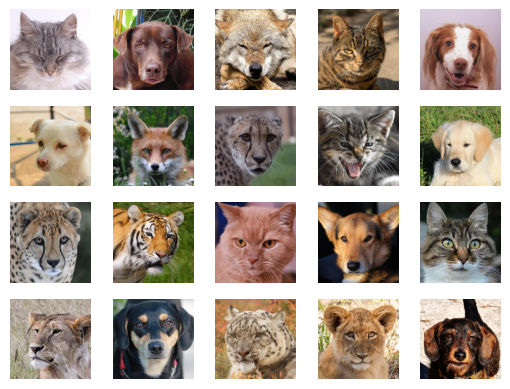

In [10]:
n_rows= 4
n_cols =5
f, axarr = plt.subplots(n_rows ,n_cols)
for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n = 1)['Image_paths'].iloc[0]).convert('RGB')
    axarr[row ,col].imshow(image)
    axarr[row ,col].axis('off')
plt.show()

# Hyperparameters

In [11]:
LR = 1e-4
BATCH_SIZE =16
EPOCH= 10

# DATALOADER

In [12]:
train_loader = DataLoader(train_dataset,batch_size = BATCH_SIZE ,shuffle =True)
val_loader = DataLoader(val_dataset , batch_size=BATCH_SIZE , shuffle = True)
test_loader = DataLoader(test_dataset , batch_size= BATCH_SIZE , shuffle=True)

# Model Convolutional Neural Network

In [13]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3,32 , kernel_size=3 ,padding=1) # first convolutional layer
    self.conv2 = nn.Conv2d(32 ,64 ,kernel_size=3 ,padding=1) # second convolutional layer
    self.conv3 = nn.Conv2d(64 ,128 ,kernel_size=3 ,padding =1) # Third Convolutional layer
    self.pooling = nn.MaxPool2d(2,2) # pooling layer , we will use the same layer after each conv2d
    self.relu = nn.ReLU()  # RElu activation function

    self.flatten = nn.Flatten()  # Flatten and vectorize the output feature map that comes from the final covolutional layer
    self.linear = nn.Linear((128 * 16 * 16) , 128)  # Traditional dense linear
    self.output = nn.Linear(128 , len(data_df['labels'].unique()))  # output linear layer

  def forward(self , x):
    x = self.conv1(x)   # outputs :-> (32, 128 , 128)
    x = self.pooling(x) # output : (32 ,64 ,64)
    x = self.relu(x)

    x = self.conv2(x)   # output : (64, 64, 64)
    x = self.pooling(x) # output : (64 ,32 ,32)
    x = self.relu(x)

    x = self.conv3(x)   # output : (128 , 32 ,32)
    x = self.pooling(x) # output : (128 , 16, 16)
    x = self.relu(x)
    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x
Model = Net().to(device)

# Model Summary

In [14]:
from torchsummary import summary
summary(Model , input_size= (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

# Loss and Optimizer

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(Model.parameters() ,lr = LR)

In [20]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCH):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs , labels in train_loader:
    optimizer.zero_grad()
    outputs = Model(inputs)
    train_loss = criterion(outputs ,labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs ,axis=1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs , labels in val_loader:
      outputs = Model(inputs)
      val_loss = criterion(outputs , labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs , axis=1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCH):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs , labels in train_loader:
    optimizer.zero_grad()
    outputs = Model(inputs)
    train_loss = criterion(outputs ,labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs ,axis=1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs , labels in val_loader:
      outputs = Model(inputs)
      val_loss = criterion(outputs , labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs , axis=1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/val_dataset.__len__()*100, 4))
  print(f'''Epoch  {epoch+1}/{EPOCH} , Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
            Validation loss : {round(total_loss_val/100 ,4)} Validation Accuracy {round((total_acc_val)/val_dataset.__len__()*100, 4)}''')
  print("="*25)

Epoch  1/10 , Train Loss: 0.1194 Train Accuracy 99.4155
            Validation loss : 0.1514 Validation Accuracy 97.1488
Epoch  2/10 , Train Loss: 0.0784 Train Accuracy 99.7166
            Validation loss : 0.1404 Validation Accuracy 97.438
Epoch  3/10 , Train Loss: 0.0629 Train Accuracy 99.7077
            Validation loss : 0.165 Validation Accuracy 96.9421
Epoch  4/10 , Train Loss: 0.0843 Train Accuracy 99.628
            Validation loss : 0.1842 Validation Accuracy 96.6116
Epoch  5/10 , Train Loss: 0.0562 Train Accuracy 99.7609
            Validation loss : 0.1739 Validation Accuracy 97.2314
Epoch  6/10 , Train Loss: 0.0198 Train Accuracy 99.938
            Validation loss : 0.1931 Validation Accuracy 97.1074
Epoch  7/10 , Train Loss: 0.0867 Train Accuracy 99.6015
            Validation loss : 0.2103 Validation Accuracy 96.5702
Epoch  8/10 , Train Loss: 0.0503 Train Accuracy 99.7874
            Validation loss : 0.2417 Validation Accuracy 95.9091
Epoch  9/10 , Train Loss: 0.038 Trai

# Testing

In [21]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs , labels in test_loader:
    preds = Model(inputs)
    acc=  (torch.argmax(preds , axis =1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(preds ,labels)
    total_loss_test += test_loss.item()

print(f"Accuracy score is {round((total_acc_test/test_dataset.__len__()) * 100,4)} and loss is {round(total_loss_test/1000 ,4)}")

Accuracy score is 95.1633 and loss is 0.0286


# Plotting and Training Progress

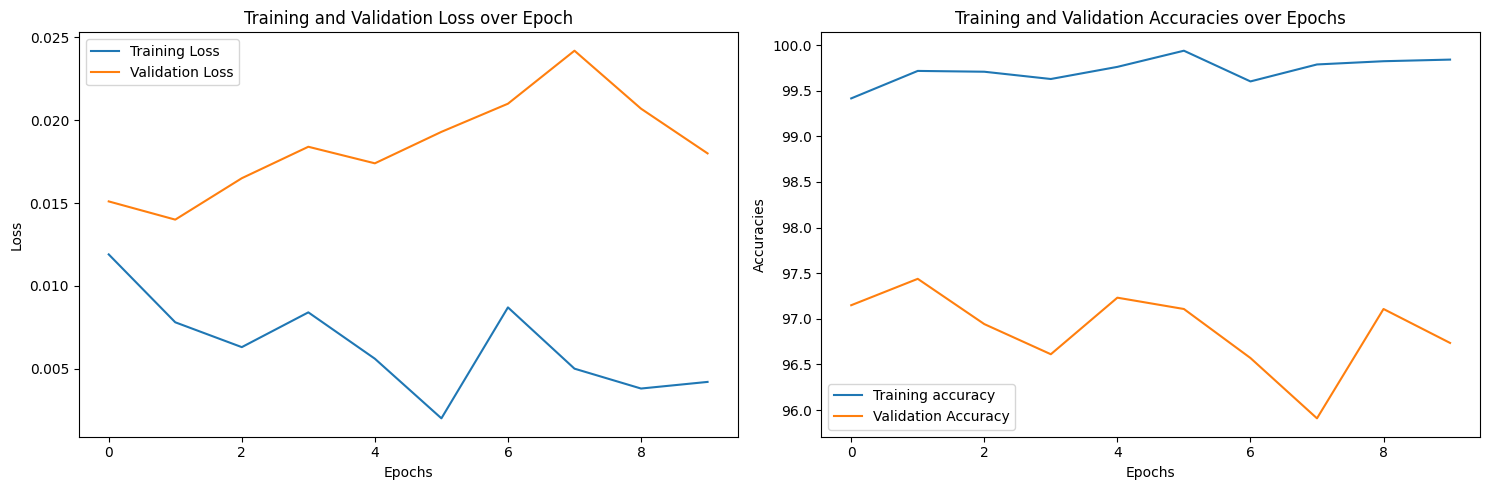

In [22]:
fig ,axis = plt.subplots(nrows=1 , ncols=2 , figsize= (15, 5))

axis[0].plot(total_loss_train_plot , label = 'Training Loss')
axis[0].plot(total_loss_validation_plot , label = 'Validation Loss')
axis[0].set_title("Training and Validation Loss over Epoch")
axis[0].set_xlabel('Epochs')
axis[0].set_ylabel("Loss")
axis[0].legend()

axis[1].plot(total_acc_train_plot , label='Training accuracy')
axis[1].plot(total_acc_validation_plot , label = 'Validation Accuracy')
axis[1].set_title('Training and Validation Accuracies over Epochs')
axis[1].set_xlabel('Epochs')
axis[1].set_ylabel('Accuracies')
axis[1].legend()

plt.tight_layout()
plt.show()

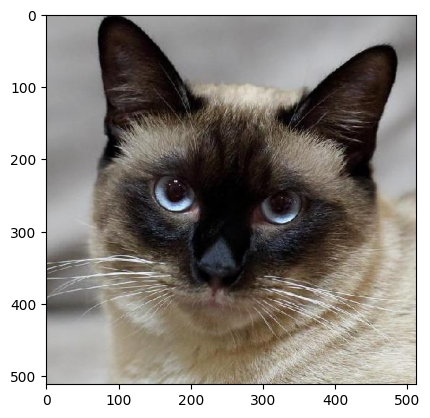


Prediction: 



array(['cat'], dtype=object)

In [25]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = Model(image.unsqueeze(0))
  output = torch.argmax(output ,axis = 1).item()
  return label_encoder.inverse_transform([output])

image = Image.open("/content/animal-faces/afhq/train/cat/pixabay_cat_000196.jpg")
plt.imshow(image)
plt.show()

# predict
print()
print("Prediction: \n")
predict_image("/content/animal-faces/afhq/train/cat/pixabay_cat_000196.jpg")